<a href="https://colab.research.google.com/github/RachnaRamesh/BlockchainProject/blob/main/NewAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/data.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_excel('/content/drive/My Drive/data.xlsx')

print(df.info())
print(df.describe())

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377719 entries, 0 to 377718
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   time                      377719 non-null  datetime64[ns]
 1   Cyclone_Inlet_Gas_Temp    377719 non-null  object        
 2   Cyclone_Material_Temp     377719 non-null  object        
 3   Cyclone_Outlet_Gas_draft  377719 non-null  object        
 4   Cyclone_cone_draft        377719 non-null  object        
 5   Cyclone_Gas_Outlet_Temp   377719 non-null  object        
 6   Cyclone_Inlet_Draft       377719 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 20.2+ MB
None
                             time
count                      377719
mean   2018-10-20 02:10:21.647840
min           2017-01-01 00:00:00
25%           2017-11-24 21:07:30
50%           2018-10-19 18:10:00
75%           2019-09-13 15:12:30
max           2020-0

In [ ]:
numeric_columns = [
    'Cyclone_Inlet_Gas_Temp',
    'Cyclone_Material_Temp',
    'Cyclone_Outlet_Gas_draft',
    'Cyclone_cone_draft',
    'Cyclone_Gas_Outlet_Temp',
    'Cyclone_Inlet_Draft'
]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.isnull().sum())

time                           0
Cyclone_Inlet_Gas_Temp      1320
Cyclone_Material_Temp       1591
Cyclone_Outlet_Gas_draft    1321
Cyclone_cone_draft          1320
Cyclone_Gas_Outlet_Temp     1321
Cyclone_Inlet_Draft         1322
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
numeric_columns = [
    'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp',
    'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft',
    'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft'
]
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

In [ ]:
df[numeric_columns] = df[numeric_columns].fillna(method='ffill').fillna(method='bfill')

<ipython-input-6-ae173eac1f87>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_columns] = df[numeric_columns].fillna(method='ffill').fillna(method='bfill')


In [ ]:
print(df.isnull().sum())

time                        0
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


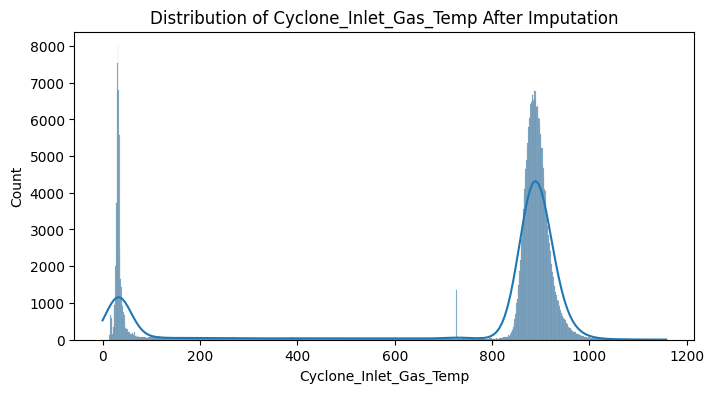

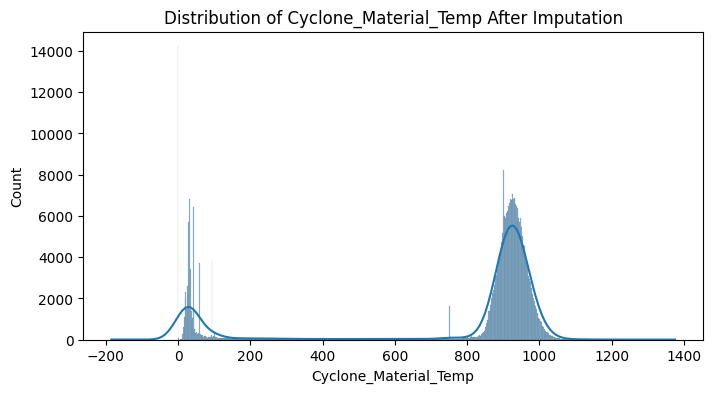

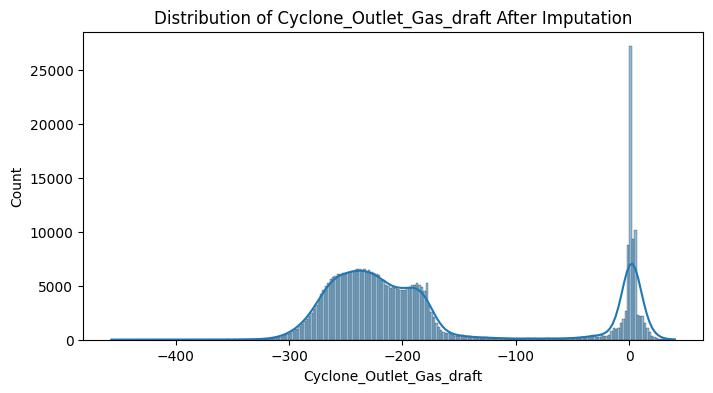

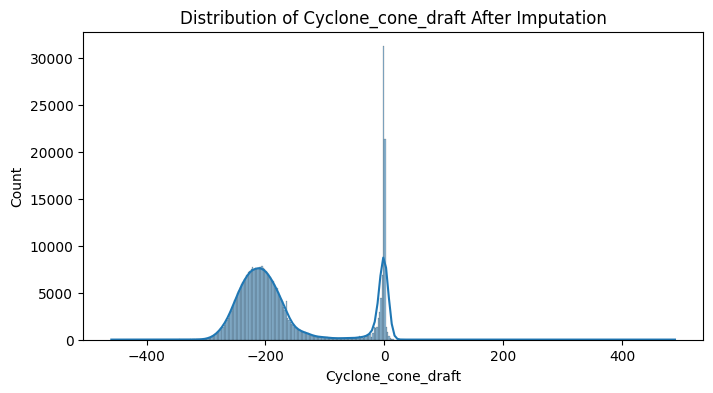

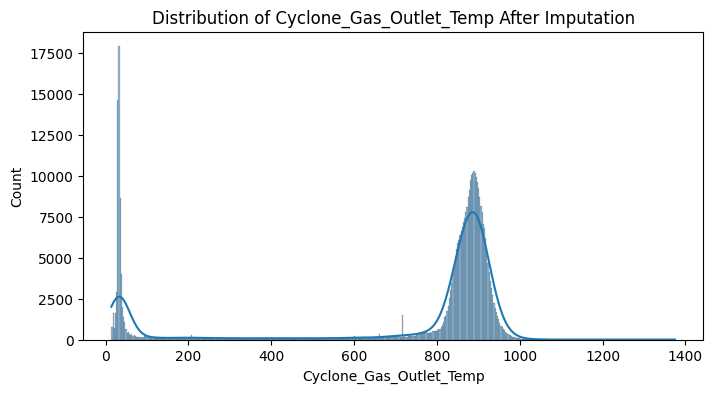

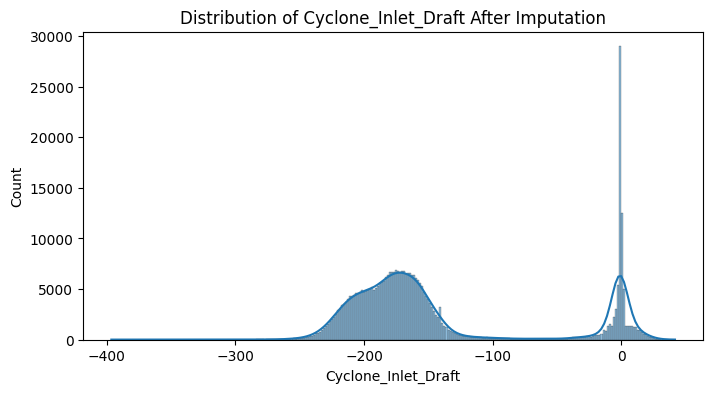

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} After Imputation')
    plt.show()

In [ ]:
print(df.describe())

                             time  Cyclone_Inlet_Gas_Temp  \
count                      377719           377719.000000   
mean   2018-10-20 02:10:21.647840              727.348549   
min           2017-01-01 00:00:00                0.000000   
25%           2017-11-24 21:07:30              855.580000   
50%           2018-10-19 18:10:00              882.250000   
75%           2019-09-13 15:12:30              901.040000   
max           2020-08-07 12:15:00             1157.630000   
std                           NaN              328.090023   

       Cyclone_Material_Temp  Cyclone_Outlet_Gas_draft  Cyclone_cone_draft  \
count          377719.000000             377719.000000       377719.000000   
mean              750.830483               -177.820685         -164.572619   
min              -185.000000               -456.660000         -459.310000   
25%               866.335000               -247.080000         -226.670000   
50%               913.070000               -214.980000      

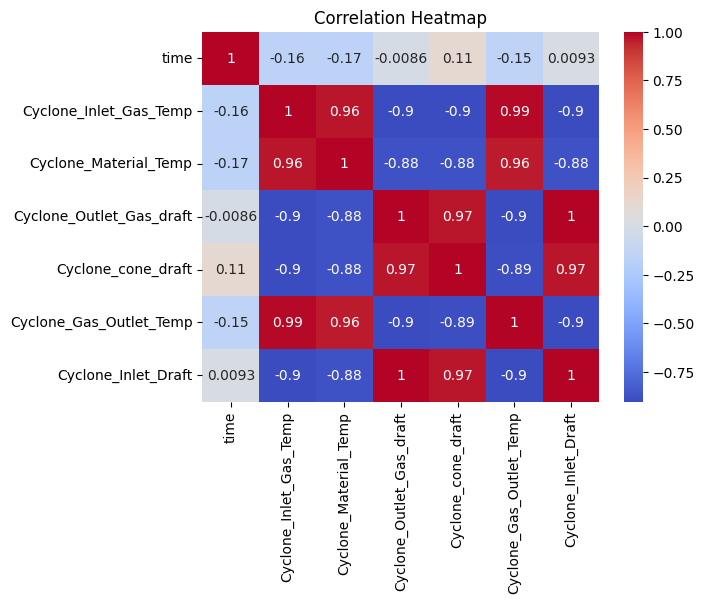

In [ ]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek

In [ ]:
df['temp_diff'] = df['Cyclone_Inlet_Gas_Temp'] - df['Cyclone_Material_Temp']
df['draft_diff'] = df['Cyclone_Inlet_Draft'] - df['Cyclone_cone_draft']

In [ ]:
df['temp_rolling_avg'] = df['Cyclone_Inlet_Gas_Temp'].rolling(window=10).mean()
df['temp_rolling_std'] = df['Cyclone_Inlet_Gas_Temp'].rolling(window=10).std()

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_columns = ['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft',
                   'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_columns])

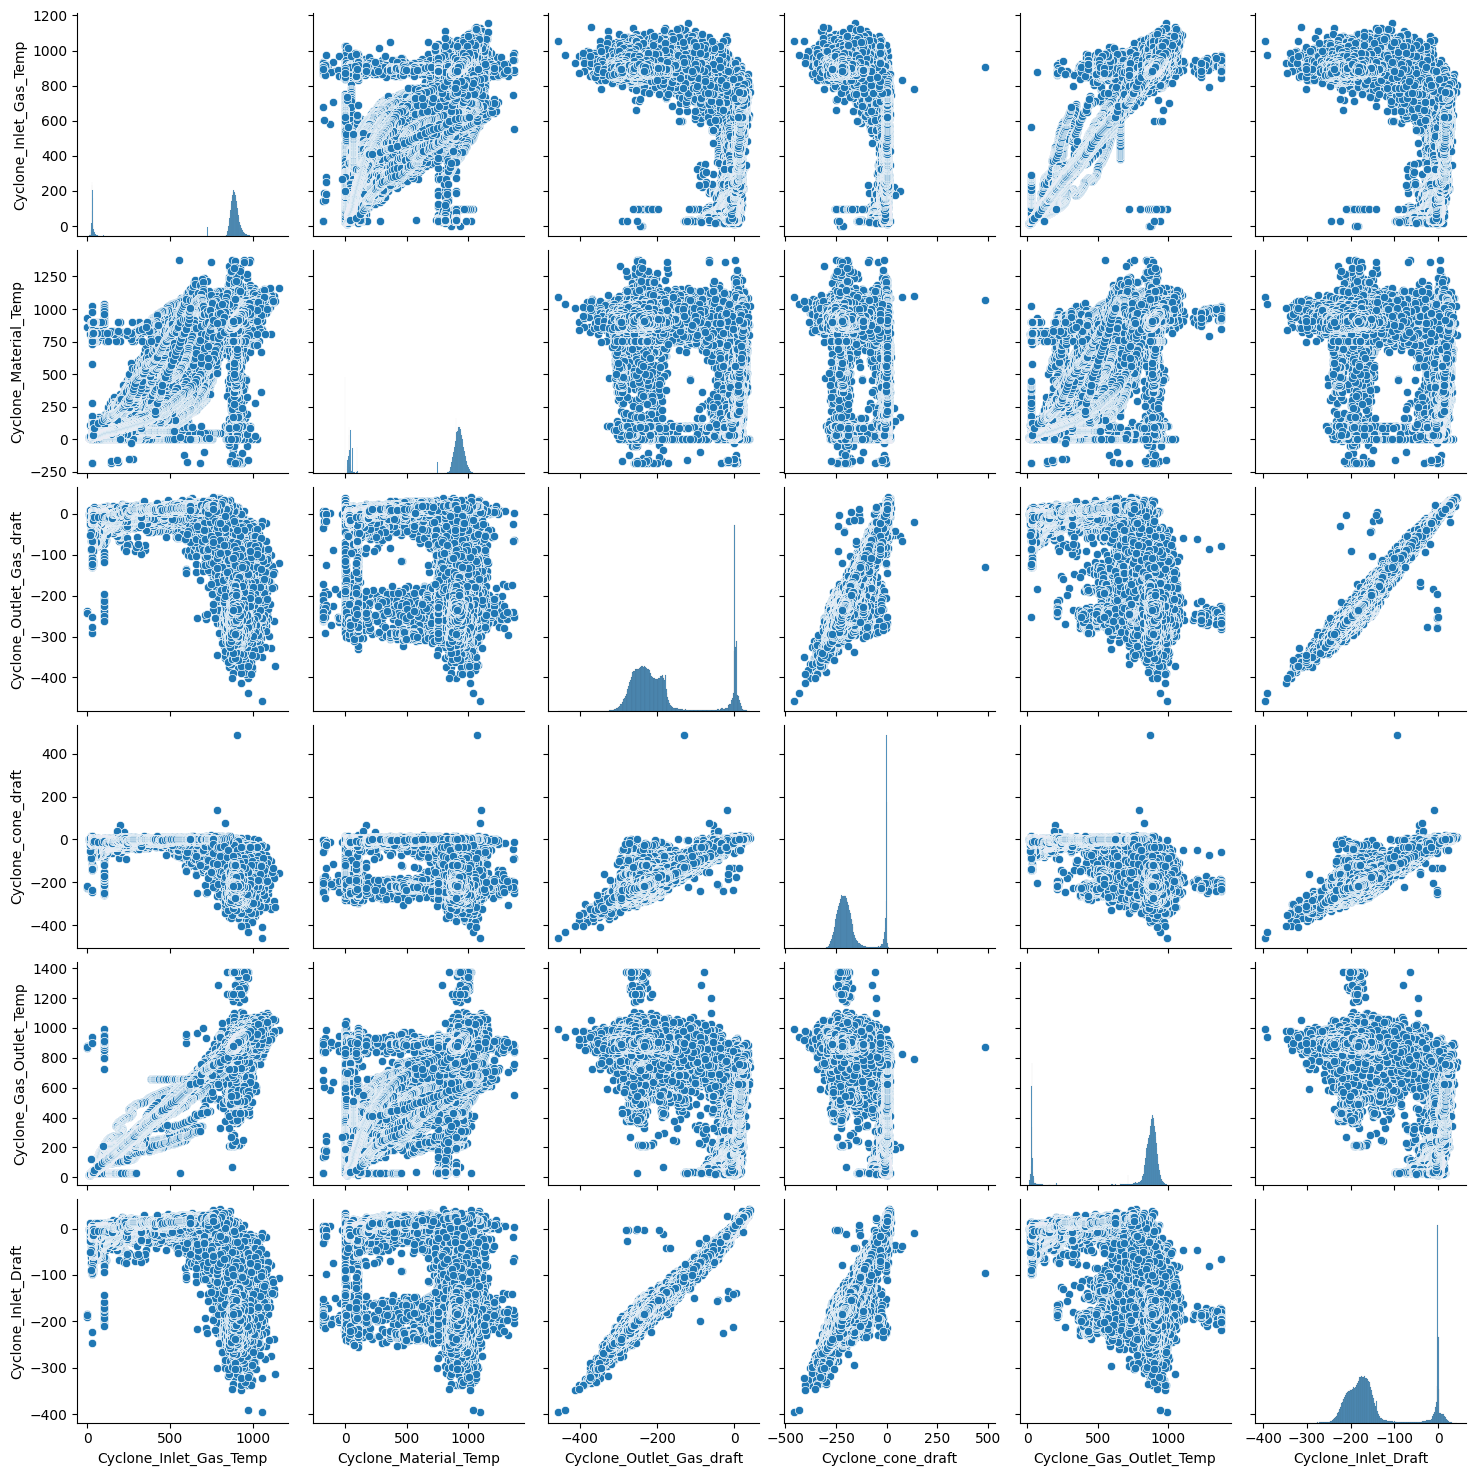

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft',
                 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']])
plt.show()

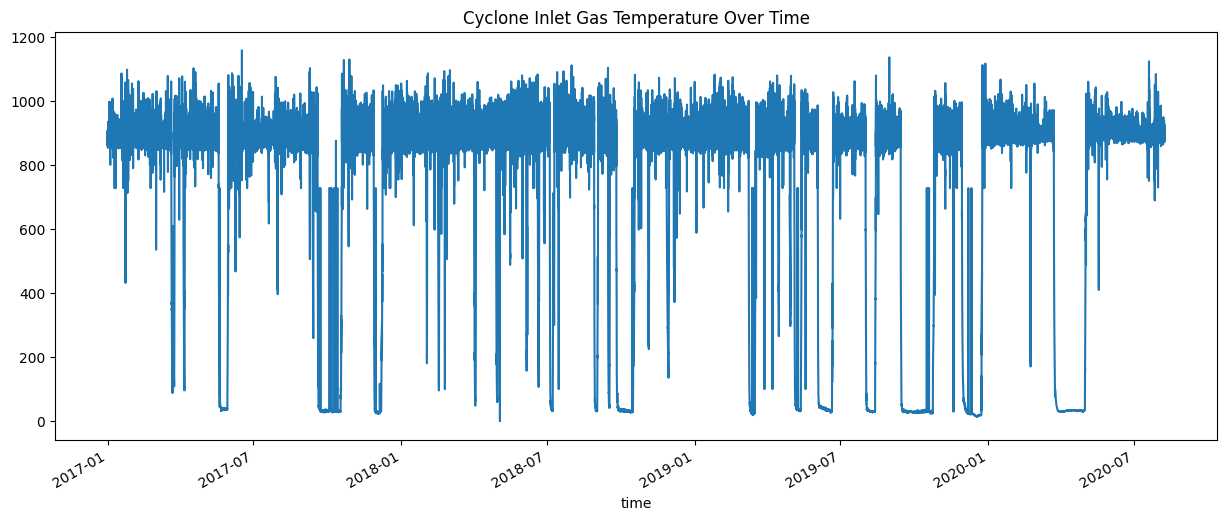

In [ ]:
df.set_index('time', inplace=True)
df['Cyclone_Inlet_Gas_Temp'].plot(figsize=(15, 6), title='Cyclone Inlet Gas Temperature Over Time')
plt.show()

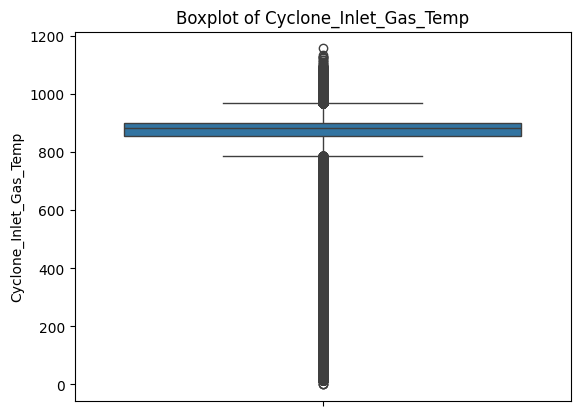

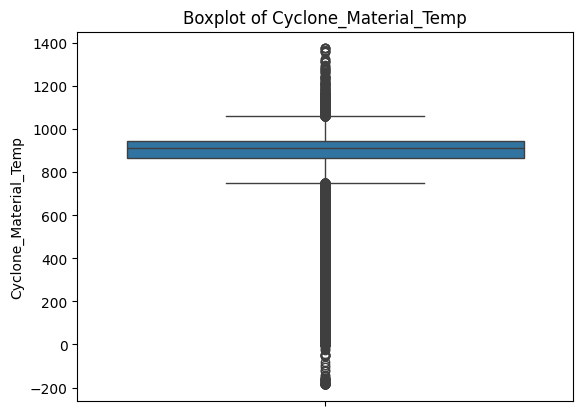

In [ ]:
for col in ['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp']:
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

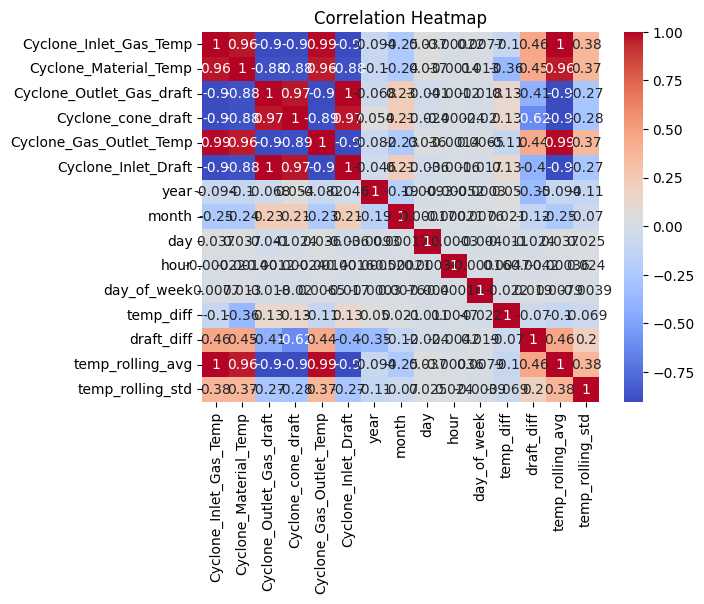

In [ ]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


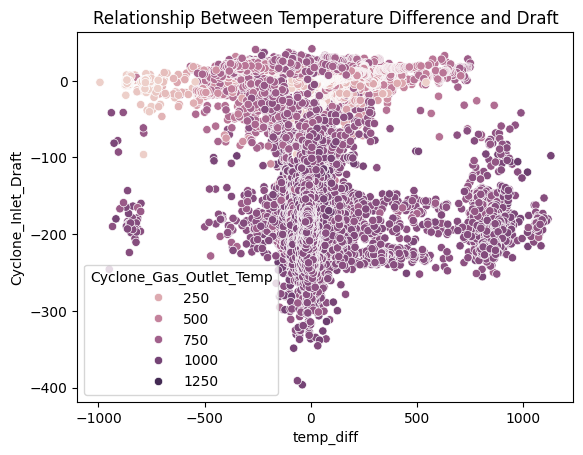

In [ ]:
sns.scatterplot(x='temp_diff', y='Cyclone_Inlet_Draft', data=df, hue='Cyclone_Gas_Outlet_Temp')
plt.title('Relationship Between Temperature Difference and Draft')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df[numeric_columns], test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [ ]:
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(train_scaled)
iso_forest_preds = iso_forest.predict(test_scaled)

In [ ]:
from sklearn.svm import OneClassSVM
ocsvm = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
ocsvm.fit(train_scaled)
ocsvm_preds = ocsvm.predict(test_scaled)

In [ ]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
ocsvm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')

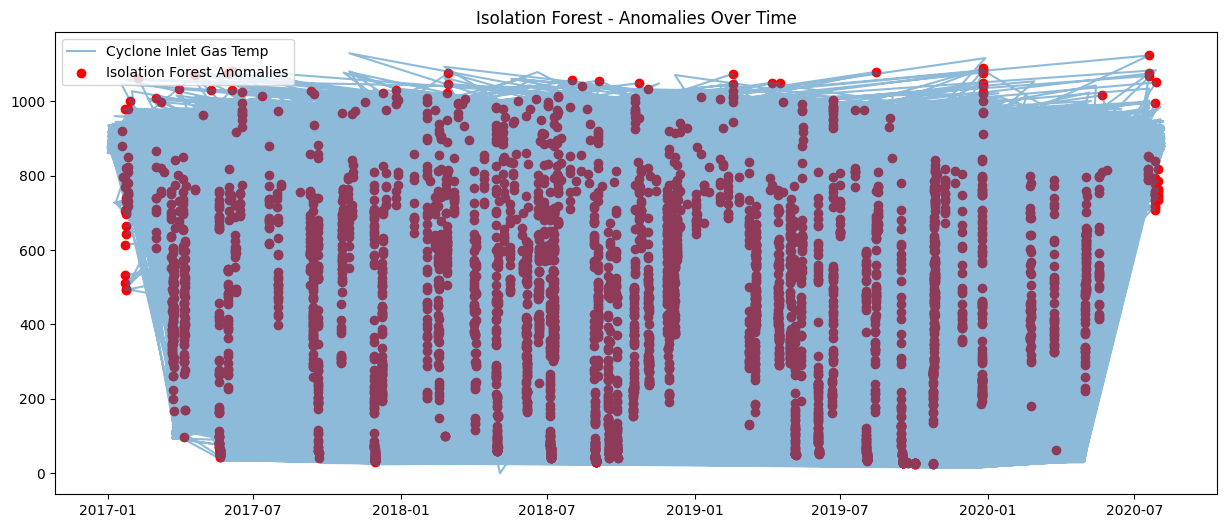

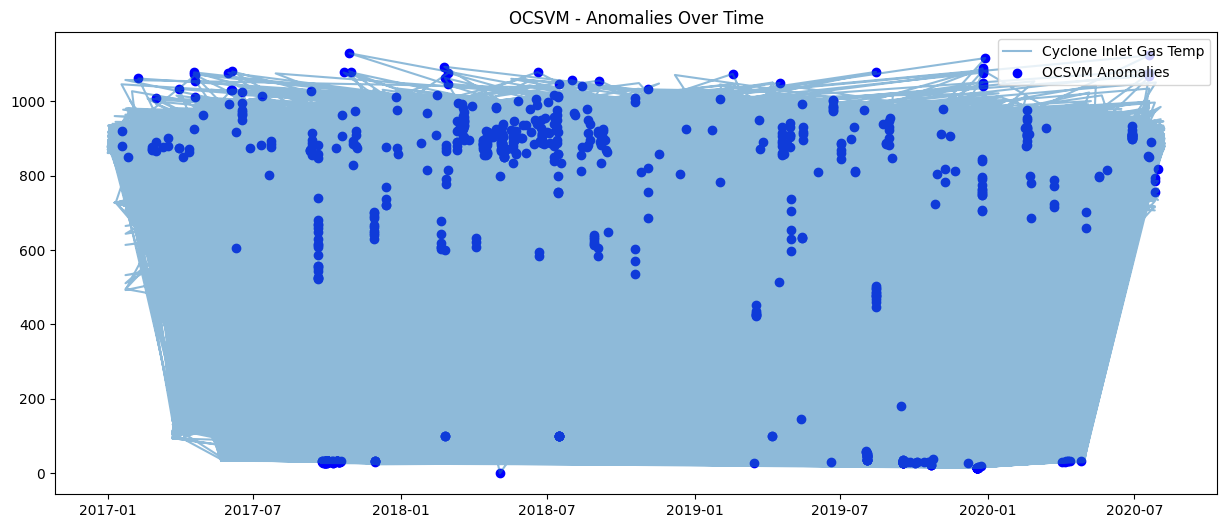

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data['Cyclone_Inlet_Gas_Temp'], alpha=0.5, label='Cyclone Inlet Gas Temp')
plt.scatter(test_data.index[iso_forest_preds == -1],
            test_data['Cyclone_Inlet_Gas_Temp'][iso_forest_preds == -1],
            color='red', label='Isolation Forest Anomalies')
plt.title("Isolation Forest - Anomalies Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data['Cyclone_Inlet_Gas_Temp'], alpha=0.5, label='Cyclone Inlet Gas Temp')
plt.scatter(test_data.index[ocsvm_preds == -1],
            test_data['Cyclone_Inlet_Gas_Temp'][ocsvm_preds == -1],
            color='blue', label='OCSVM Anomalies')
plt.title("OCSVM - Anomalies Over Time")
plt.legend()
plt.show()

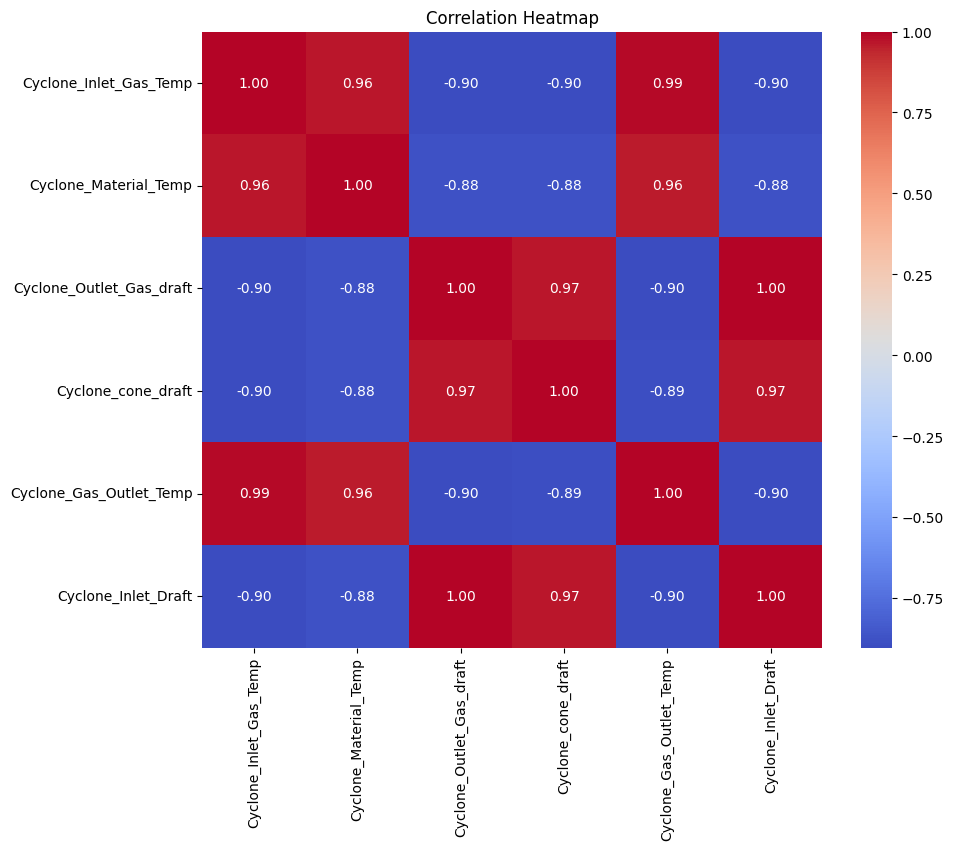

In [ ]:
import seaborn as sns

correlation_matrix = test_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable h

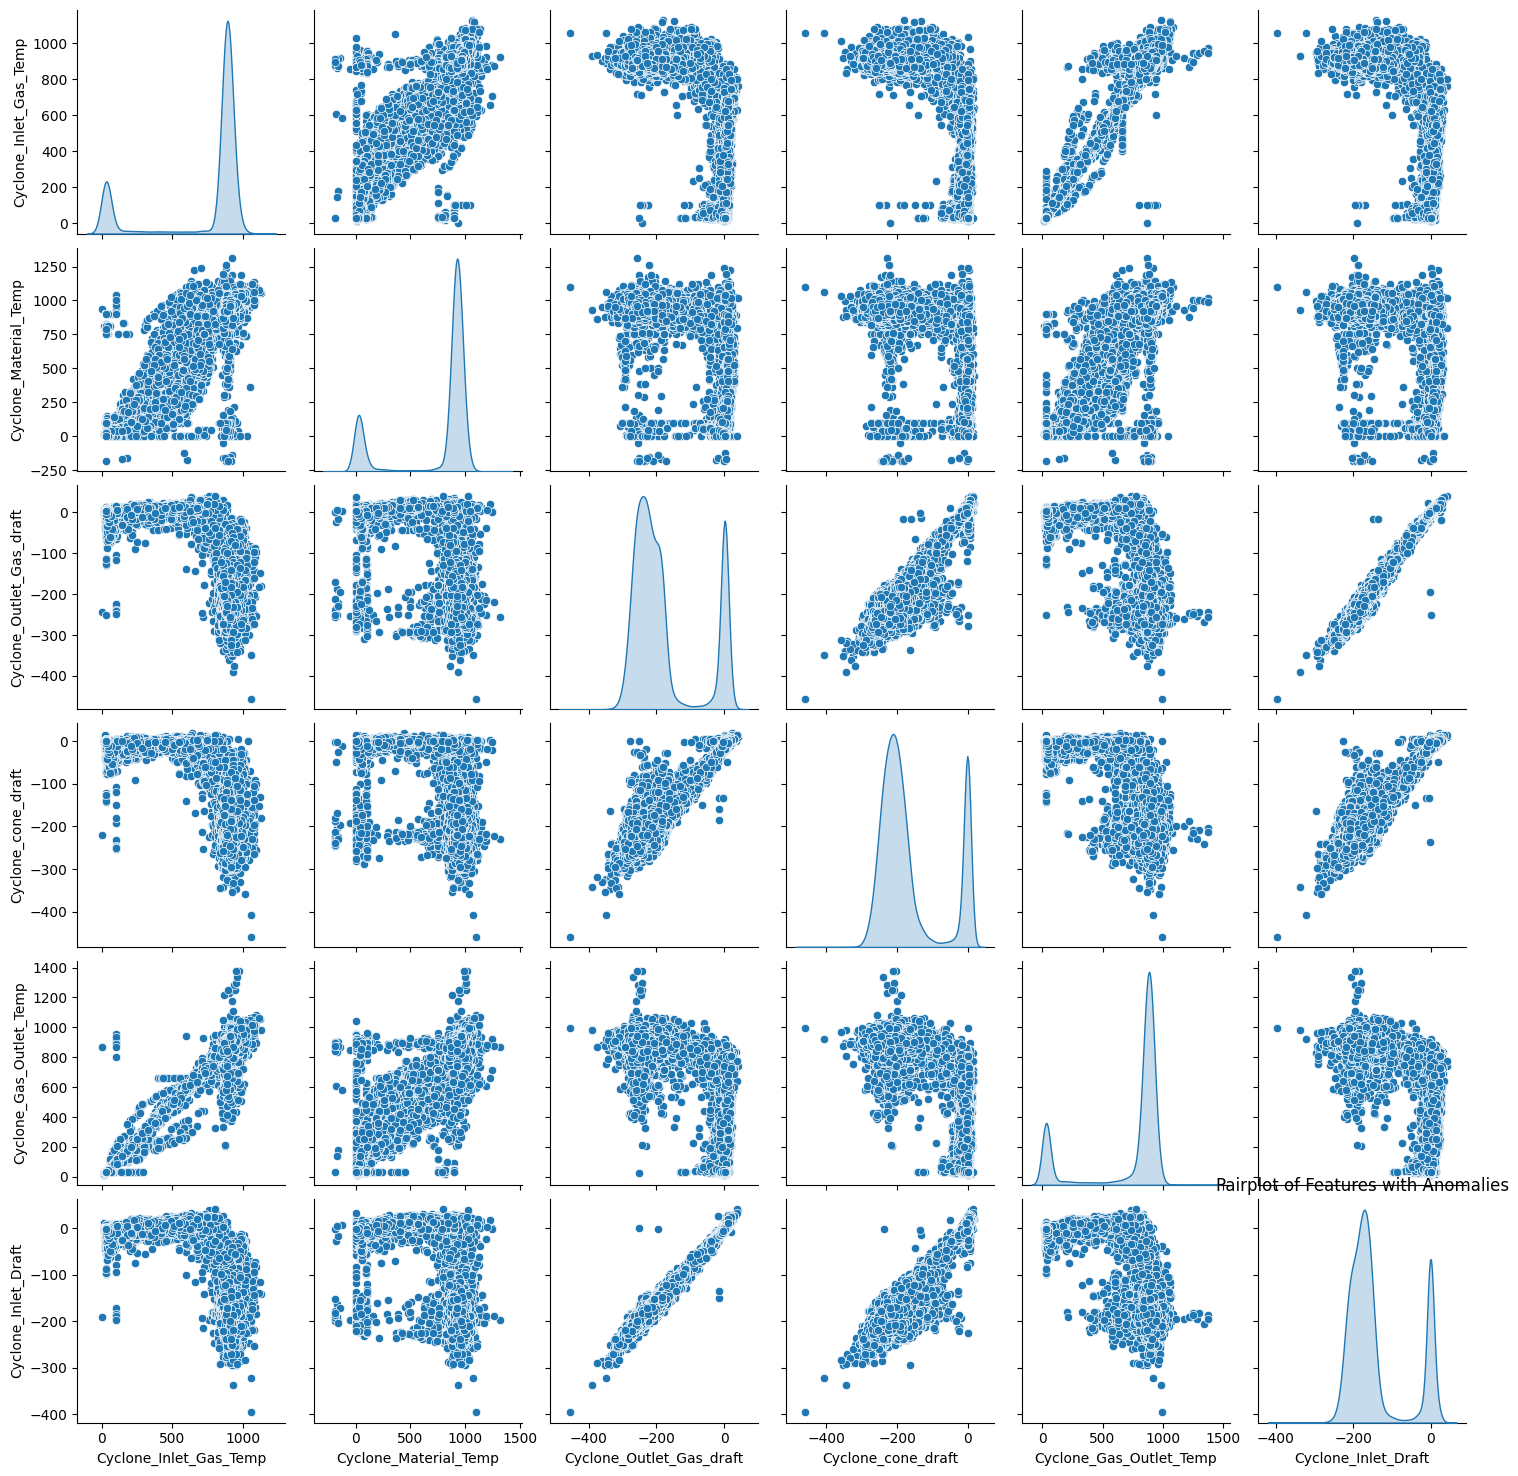

In [ ]:
sns.pairplot(test_data, diag_kind="kde", markers=["o", "s"], palette="coolwarm")
plt.title("Pairplot of Features with Anomalies")
plt.show()

In [ ]:
print("Isolation Forest - Anomaly Proportion:", (iso_forest_preds == -1).sum() / len(iso_forest_preds))
print("OCSVM - Anomaly Proportion:", (ocsvm_preds == -1).sum() / len(ocsvm_preds))

Isolation Forest - Anomaly Proportion: 0.0505533199195171
OCSVM - Anomaly Proportion: 0.009875039711955946


Number of Overlapping Anomalies Detected: 309


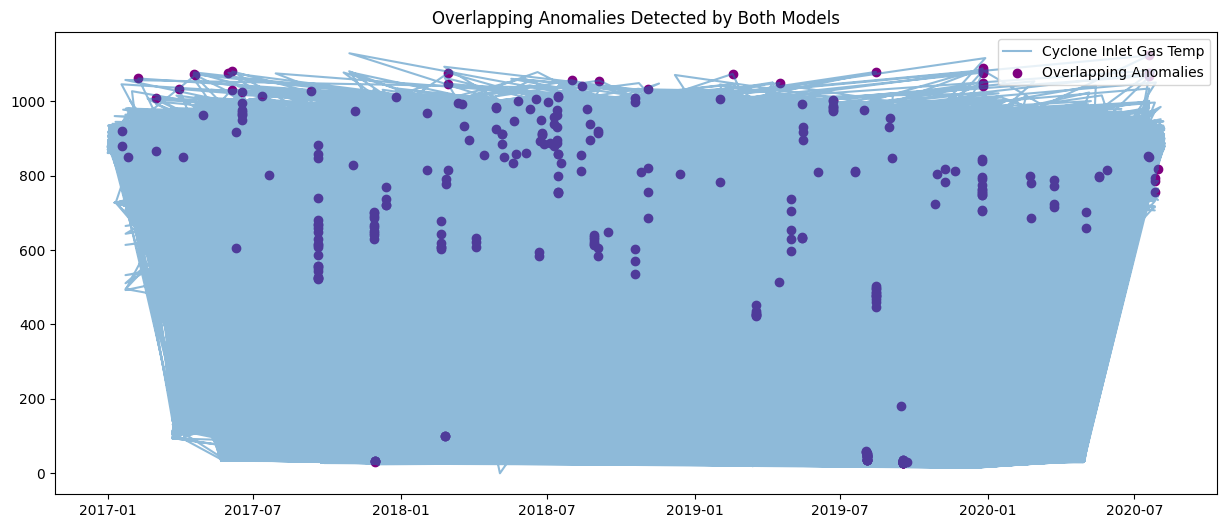

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'time': test_data.index,
    'Cyclone_Inlet_Gas_Temp': test_data['Cyclone_Inlet_Gas_Temp'],
    'iso_forest_anomaly': iso_forest_preds,
    'ocsvm_anomaly': ocsvm_preds
})

overlap = comparison_df[(comparison_df['iso_forest_anomaly'] == -1) & (comparison_df['ocsvm_anomaly'] == -1)]
print("Number of Overlapping Anomalies Detected:", len(overlap))

plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data['Cyclone_Inlet_Gas_Temp'], alpha=0.5, label='Cyclone Inlet Gas Temp')
plt.scatter(overlap['time'], overlap['Cyclone_Inlet_Gas_Temp'], color='purple', label='Overlapping Anomalies')
plt.title("Overlapping Anomalies Detected by Both Models")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'iso_forest_anomaly': iso_forest_preds,
    'ocsvm_anomaly': ocsvm_preds
})

overlap = comparison_df[(comparison_df['iso_forest_anomaly'] == -1) & (comparison_df['ocsvm_anomaly'] == -1)]
overlap_count = len(overlap)
print("Number of overlapping anomalies detected by both models:", overlap_count)

Number of overlapping anomalies detected by both models: 309


In [ ]:
test_data['synthetic_label'] = 1
test_data.loc[test_data['Cyclone_Inlet_Gas_Temp'] > 800, 'synthetic_label'] = -1
y_synthetic = test_data['synthetic_label']

In [ ]:
from sklearn.metrics import classification_report

print("Isolation Forest Report:\n", classification_report(y_synthetic, iso_forest_preds))
print("OCSVM Report:\n", classification_report(y_synthetic, ocsvm_preds))

Isolation Forest Report:
               precision    recall  f1-score   support

          -1       0.08      0.01      0.01     58949
           1       0.18      0.79      0.30     16595

    accuracy                           0.18     75544
   macro avg       0.13      0.40      0.15     75544
weighted avg       0.10      0.18      0.07     75544

OCSVM Report:
               precision    recall  f1-score   support

          -1       0.53      0.01      0.01     58949
           1       0.22      0.98      0.36     16595

    accuracy                           0.22     75544
   macro avg       0.37      0.49      0.18     75544
weighted avg       0.46      0.22      0.09     75544



In [ ]:
ocsvm = OneClassSVM(nu=0.02, kernel='rbf', gamma='scale')
ocsvm.fit(train_scaled)
ocsvm_preds = ocsvm.predict(test_scaled)

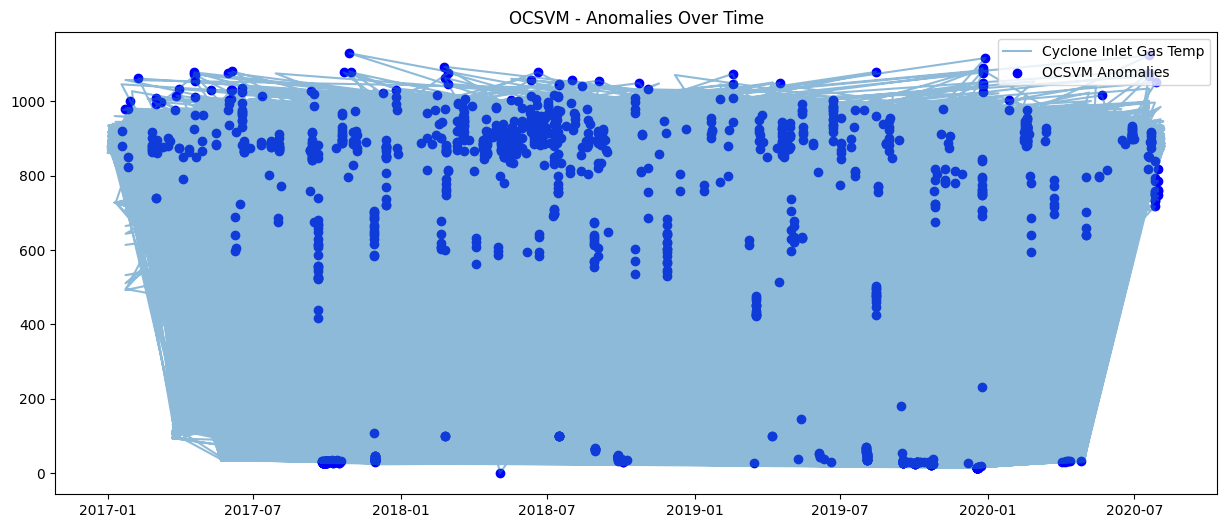

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data['Cyclone_Inlet_Gas_Temp'], alpha=0.5, label='Cyclone Inlet Gas Temp')
plt.scatter(test_data.index[ocsvm_preds == -1],
            test_data['Cyclone_Inlet_Gas_Temp'][ocsvm_preds == -1],
            color='blue', label='OCSVM Anomalies')
plt.title("OCSVM - Anomalies Over Time")
plt.legend()
plt.show()

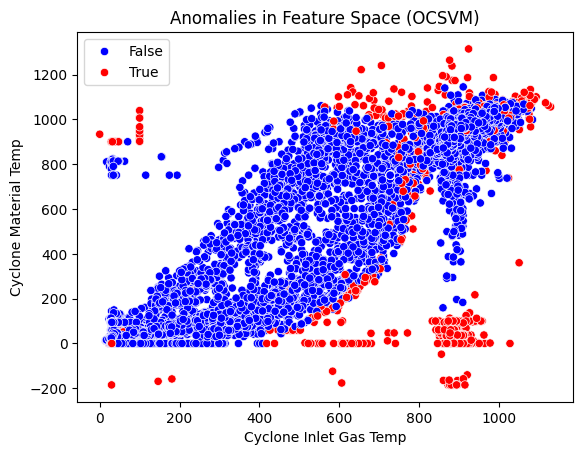

In [ ]:
import seaborn as sns

sns.scatterplot(
    x=test_data['Cyclone_Inlet_Gas_Temp'],
    y=test_data['Cyclone_Material_Temp'],
    hue=(ocsvm_preds == -1),
    palette={True: "red", False: "blue"}
)
plt.title("Anomalies in Feature Space (OCSVM)")
plt.xlabel("Cyclone Inlet Gas Temp")
plt.ylabel("Cyclone Material Temp")
plt.show()

In [ ]:
print("Proportion of Anomalies Detected:", (ocsvm_preds == -1).sum() / len(ocsvm_preds))

Proportion of Anomalies Detected: 0.019432383776342266


In [ ]:
anomalous_periods = test_data[ocsvm_preds == -1]
print("Anomalous Periods:\n", anomalous_periods)


Anomalous Periods:
                      Cyclone_Inlet_Gas_Temp  Cyclone_Material_Temp  \
time                                                                 
2020-07-19 08:05:00                 1068.09                1090.80   
2018-04-17 03:15:00                  882.88                 931.49   
2020-02-18 01:10:00                  882.46                 888.37   
2017-11-29 04:00:00                   39.68                  44.40   
2020-06-18 20:10:00                  885.92                 875.78   
...                                     ...                    ...   
2018-09-15 09:05:00                  648.98                1104.84   
2019-10-22 10:50:00                   27.06                   0.00   
2018-06-18 10:05:00                  917.83                 949.86   
2019-10-04 19:10:00                   30.11                   0.00   
2017-12-12 21:35:00                  877.19                  46.85   

                     Cyclone_Outlet_Gas_draft  Cyclone_cone_draft  \


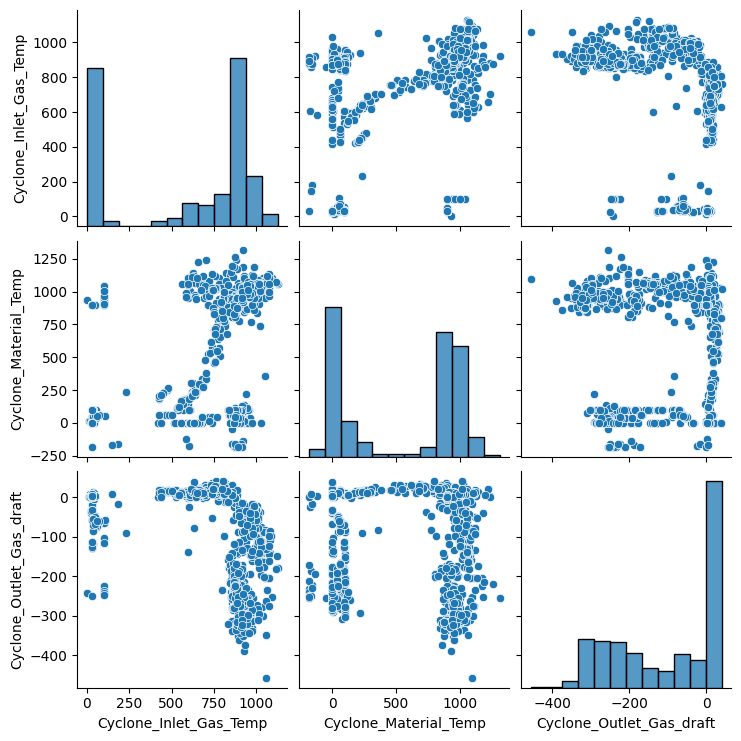

In [ ]:
sns.pairplot(anomalous_periods[['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft']])
plt.show()